In [7]:
#Datset loading 

import pandas as pd

# Path to the dataset
DATA_PATH = "/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH)

# Display the number of rows and columns
print(df.shape)

(200, 5)


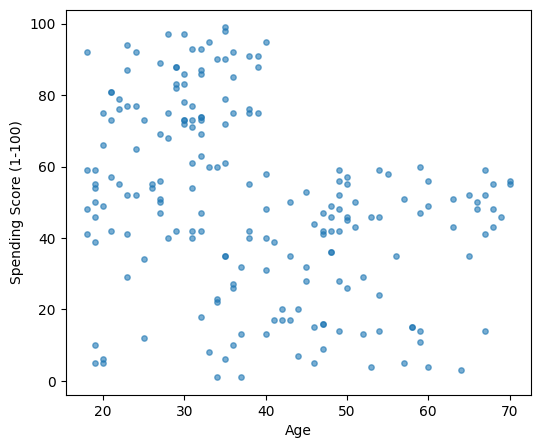

In [8]:
#Visualization

import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(6, 5))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"],
    s=15,
    alpha=0.6
)

# Add labels
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")

# Display the plot
plt.show()

In [9]:
#Preprocessing

from sklearn.preprocessing import StandardScaler

# Select features
X = df[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


In [11]:
#Training 

from sklearn.cluster import KMeans

# Create the K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Fit the model
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [12]:
#Testing

df["Cluster"] = kmeans.predict(X_scaled)

print(df["Cluster"].value_counts())


Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


In [13]:
#Validation

from sklearn.metrics import silhouette_score

# Calculate and display the Silhouette Score
print(silhouette_score(X_scaled, df["Cluster"]))

# Calculate the average values for each cluster
print(
    df.groupby("Cluster")[
        ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
    ].mean()
)

0.41664341513732767
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064
